<a href="https://colab.research.google.com/github/Calebchike/Bitcoin-EDA/blob/main/Bitcoin_EDA_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Module**

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import datetime

# **Import Data**

In [59]:
file_path = "https://raw.githubusercontent.com/Calebchike/Bitcoin-EDA/refs/heads/main/bitcoin_dataset.csv"
df = pd.read_csv(file_path)
df.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


## **Duplicate dataframe and Set Date Column as index**

Create dataframe `bitcoin` a duplicate of the `df` dataframe.
Set the date column as the dataframe index.

In [60]:
bitcoin = df.copy()
bitcoin['Date'] = pd.to_datetime(df['Date'])
bitcoin.set_index('Date', inplace=True)
bitcoin.head(5)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


# **Data Visualization**


##   Bitcoin close price over time

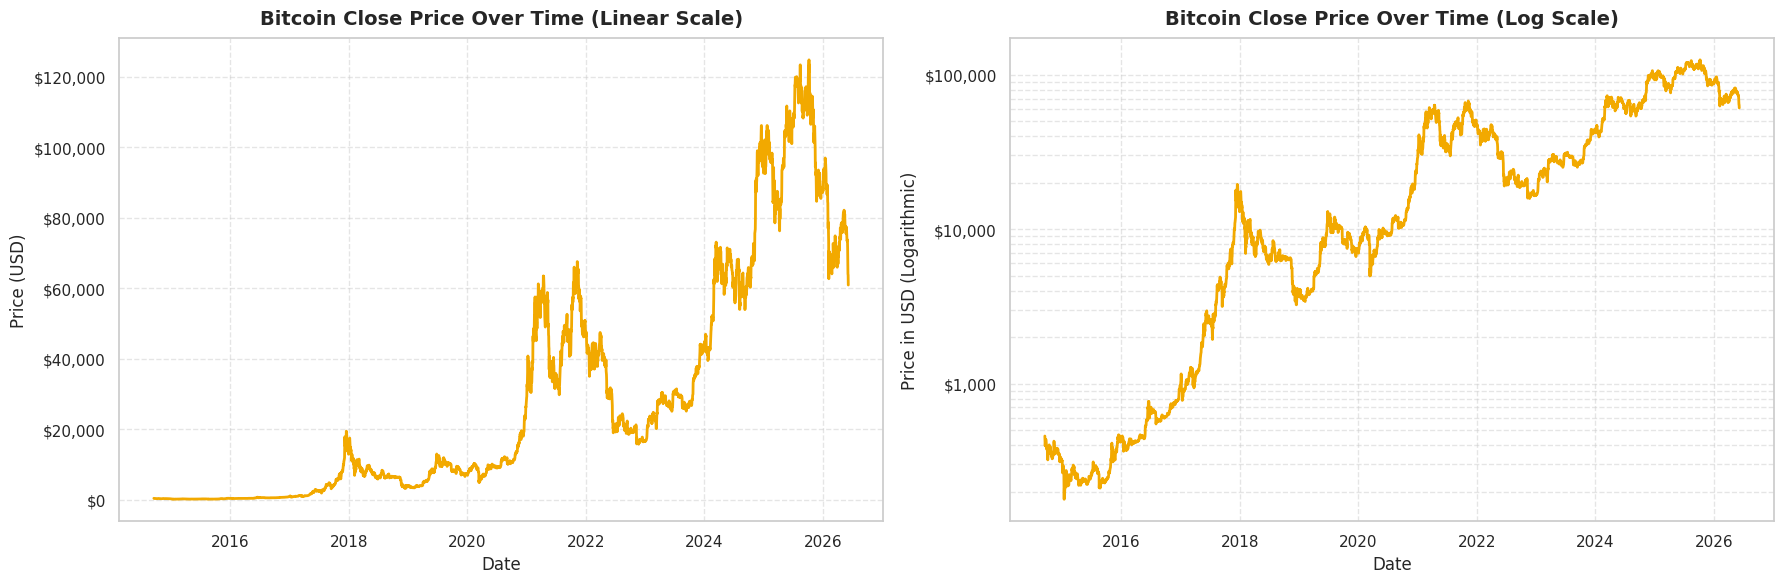

In [61]:
# Set background colour
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Standard Linear Scale ---
axes[0].plot(bitcoin.index, bitcoin['Close'], color='#f2a900', linewidth=2, label='BTC / USD')
axes[0].set_title('Bitcoin Close Price Over Time (Linear Scale)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Price (USD)', fontsize=12)
axes[0].yaxis.set_major_formatter('${x:,.0f}') # Formats numbers with commas and dollar signs
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Logarithmic Scale  ---
axes[1].plot(bitcoin.index, bitcoin['Close'], color='#f2a900', linewidth=2, label='BTC / USD')
axes[1].set_yscale('log') # Switch y-axis to log scale
axes[1].set_title('Bitcoin Close Price Over Time (Log Scale)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Price in USD (Logarithmic)', fontsize=12)
axes[1].yaxis.set_major_formatter('${x:,.0f}')

# set major and minor grid lines to show on the log scale
axes[1].grid(True, which="both", linestyle='--', alpha=0.5)

# Adjust plot layout
plt.tight_layout()
plt.show()

##  Bitcoin trading volume over time      

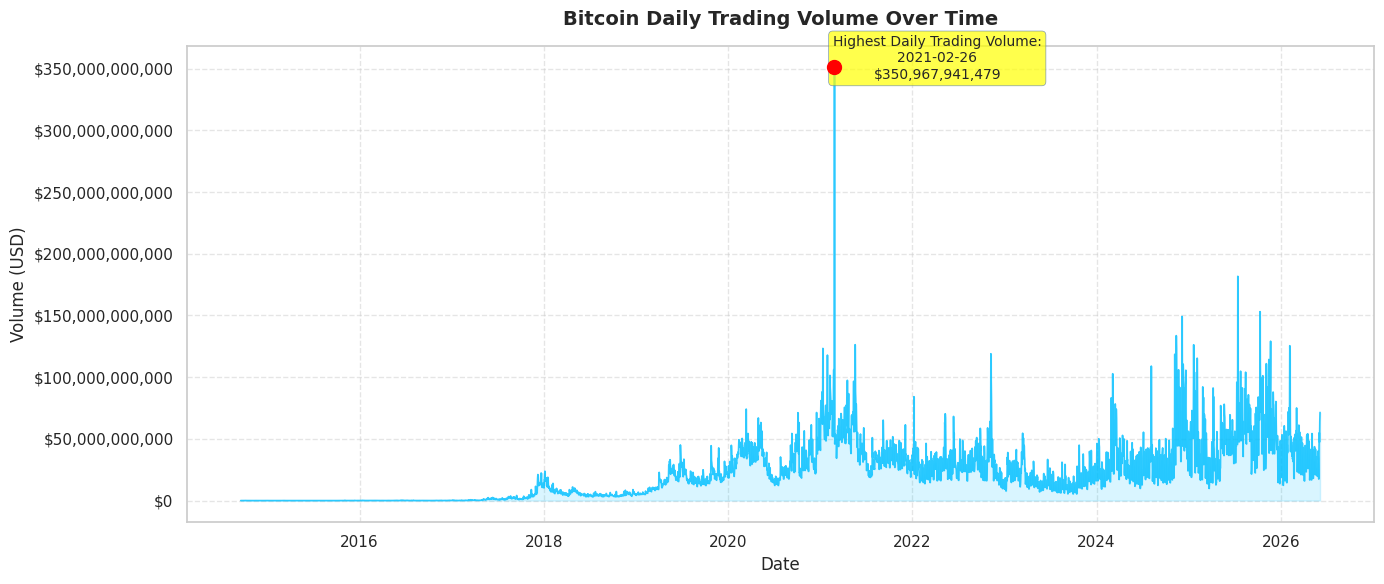

In [62]:
# Set background colour and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Renders a line graph tracking the datetime index against the volume values
plt.plot(
    bitcoin.index,
    bitcoin["Volume"],
    color="deepskyblue",
    linewidth=1.2,
    alpha=0.8,
)

# Shades the empty space under the volume plot line with a semi-transparent color block
plt.fill_between(bitcoin.index, bitcoin["Volume"], color="deepskyblue", alpha=0.15)

# Find the day with the highest trading volume
highest_volume_day = bitcoin.loc[bitcoin['Volume'].idxmax()]
highest_volume_date = highest_volume_day.name
highest_volume_value = highest_volume_day['Volume']

# Highlight the day with the highest trading volume
plt.scatter(highest_volume_date, highest_volume_value, color='red', s=100, zorder=5, label=f'Highest Volume: {highest_volume_value:,.0f}')
plt.annotate(
    f'Highest Daily Trading Volume:\n{highest_volume_date.strftime('%Y-%m-%d')}\n${highest_volume_value:,.0f}',
    (highest_volume_date, highest_volume_value),
    textcoords="offset points",
    xytext=(74,-8),
    ha='center',
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=0.5, alpha=0.7)
)

# Title formatting; bold text header above the chart workspace with custom padding
plt.title(
    "Bitcoin Daily Trading Volume Over Time",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

# Assign a descriptive text string to label the horizontal and vertical axis and sets its text scale
plt.xlabel("Date", fontsize=12)
plt.ylabel("Volume (USD)", fontsize=12)

# Select the active axes to intercept the vertical tick values and apply currency symbols and comma grouping formatting
plt.gca().yaxis.set_major_formatter("${x:,.0f}")

# Toggle visible dashed gridlines across the chart grid with reduced opacity
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

##  Close price annotated with major market events (2018 crash, 2021 peak, 2022 crash, 2024 peak)      

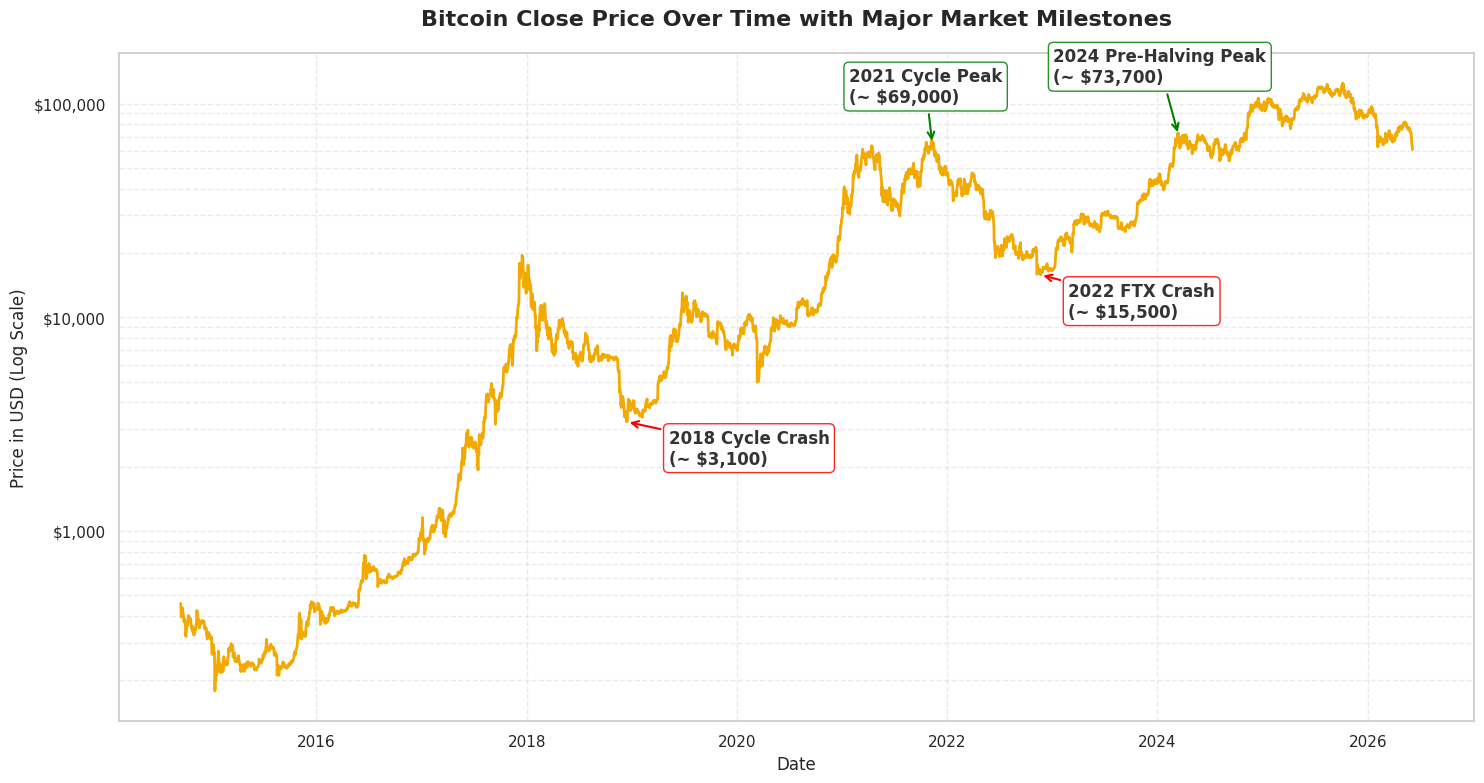

In [75]:
# Set background colour and figure size
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 8))

# Renders the baseline line graph on a logarithmic scale to account for wide cycles
ax.plot(bitcoin.index, bitcoin['Close'], color='#f2a900', linewidth=2, label='BTC / USD')
ax.set_yscale('log')

# Dictionary containing target event timestamps, price labels, and layout offsets
events = {
    '2018-12-15': {'label': '2018 Cycle Crash\n(~ $3,100)', 'xytext': (30, -30), 'color': 'red'},
    '2021-11-10': {'label': '2021 Cycle Peak\n(~ $69,000)', 'xytext': (-60, 30), 'color': 'green'},
    '2022-11-21': {'label': '2022 FTX Crash\n(~ $15,500)', 'xytext': (20, -30), 'color': 'red'},
    '2024-03-14': {'label': '2024 Pre-Halving Peak\n(~ $73,700)', 'xytext': (-90, 38), 'color': 'green'}
}

# loops through the events dictionary to apply text annotations and arrows
for date_str, info in events.items():
    date_obj = datetime.datetime.strptime(date_str, '%Y-%m-%d') # Changed plt.datetime to datetime

    # Validates that the event date exists within the active DataFrame index before plotting
    if date_obj in bitcoin.index:
        price = bitcoin.loc[date_obj, 'Close']

        ax.annotate(
            info['label'],
            xy=(date_obj, price),
            xytext=info['xytext'],
            textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=info['color'], lw=1.5),
            fontweight='bold',
            color='#333333',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=info['color'], alpha=0.85)
        )

# Formats axis parameters, labels, text headers, and ticks
ax.set_title('Bitcoin Close Price Over Time with Major Market Milestones', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price in USD (Log Scale)', fontsize=12)
ax.yaxis.set_major_formatter('${x:,.0f}')
ax.grid(True, which="both", linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('bitcoin_annotated_chart.png', dpi=300)
plt.show()

##  Daily / log returns histogram — shows fat tails, not a normal distribution

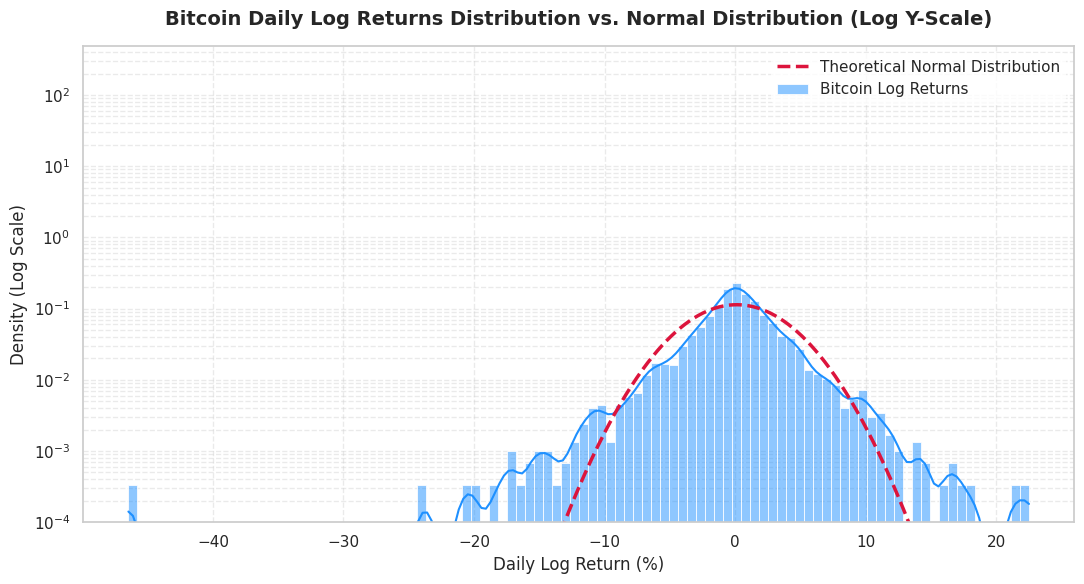

In [76]:
# Computes the continuous daily log returns by calculating the natural logarithm of price ratios
bitcoin['Log_Return'] = np.log(bitcoin['Close'] / bitcoin['Close'].shift(1)) * 100

clean_returns = bitcoin['Log_Return'].dropna()

# Instantiates a subplots container to set canvas width and height properties
fig, ax = plt.subplots(figsize=(11, 6))

# Plots the empirical returns density histogram alongside a kernel density estimate line
sns.histplot(clean_returns, bins=100, kde=True, stat="density",
             color="dodgerblue", alpha=0.5, label="Bitcoin Log Returns", ax=ax)

# Generates a linear spacing array across the span of minimum to maximum empirical values
x = np.linspace(clean_returns.min(), clean_returns.max(), 1000)

# Evaluates a standard normal probability density function matching the sample mean and variance
normal_pdf = stats.norm.pdf(x, loc=clean_returns.mean(), scale=clean_returns.std())

# Overlays the theoretical normal curve line on top of the active histogram axes
ax.plot(x, normal_pdf, color="crimson", linewidth=2.5,
        linestyle="--", label="Theoretical Normal Distribution")

# Sets the vertical density axis to a logarithmic scale to visually separate and amplify the tails
ax.set_yscale('log')

# Clamps the lower floor threshold of the logarithmic axis to eliminate visual clipping errors
ax.set_ylim(bottom=1e-4)

# Configures text strings for the plot title, horizontal measurement metrics, and vertical density labels
ax.set_title("Bitcoin Daily Log Returns Distribution vs. Normal Distribution (Log Y-Scale)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Daily Log Return (%)", fontsize=12)
ax.set_ylabel("Density (Log Scale)", fontsize=12)

# Draws primary and secondary grid meshes and renders an information legend container box
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11)

# Optimizes the bounding perimeter spacing
plt.tight_layout()
plt.show()

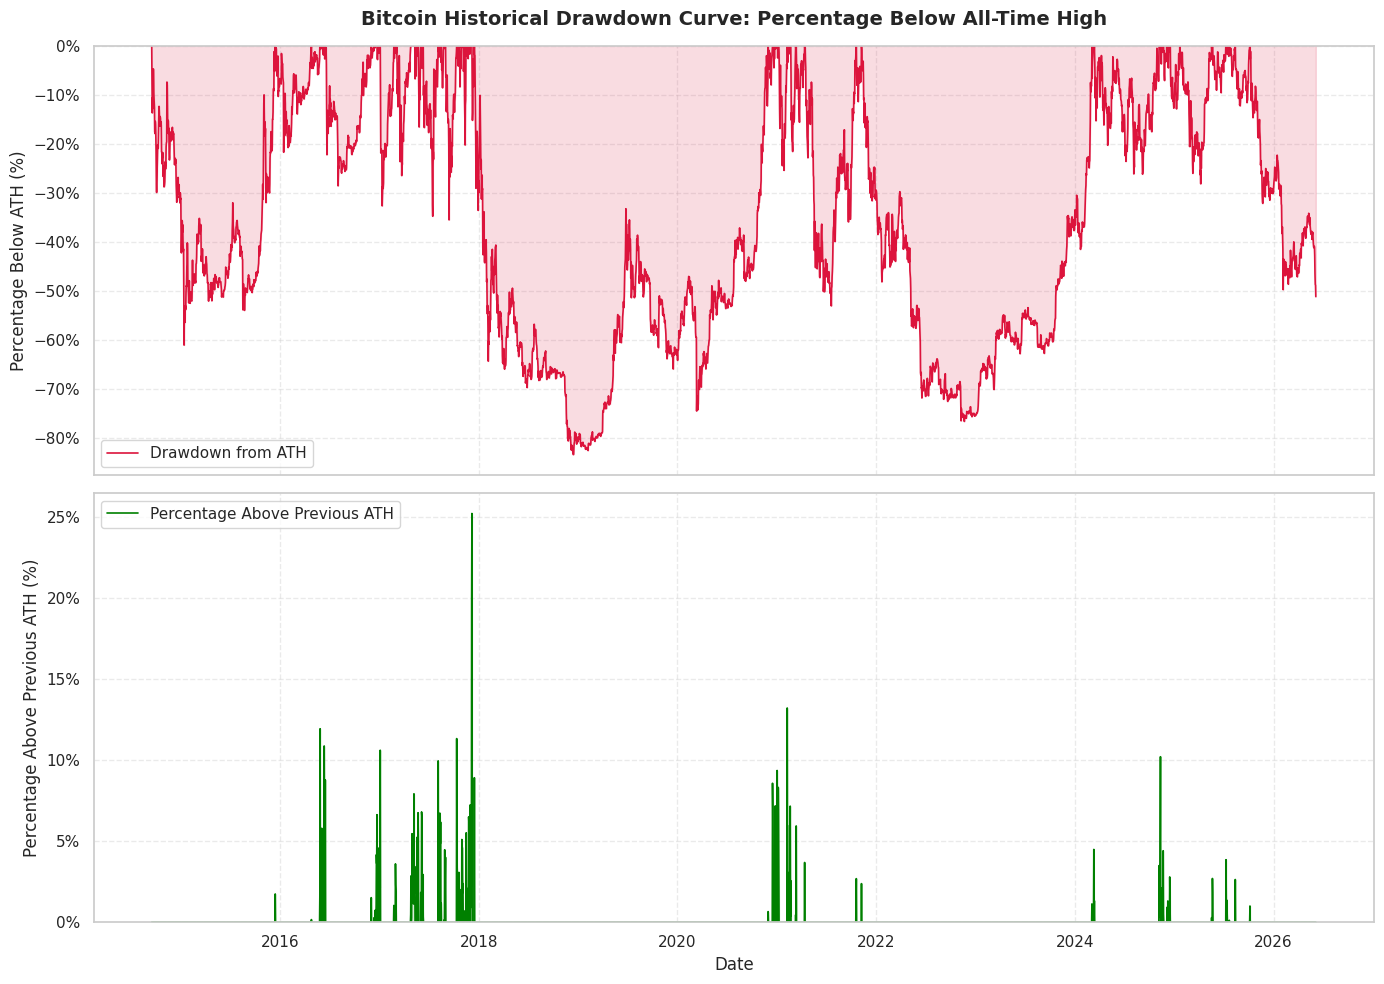

In [65]:
# Set up a professional grid style for the visualization canvas
sns.set_theme(style="whitegrid")

# Create a figure with two subplots, sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Calculate the expanding historical peak price up to each given day
rolling_max = bitcoin['Close'].cummax()

# Calculate the current percentage drop from that expanding historical peak
drawdown = ((bitcoin['Close'] - rolling_max) / rolling_max) * 100

# Render the continuous drawdown path as a solid trend line on ax1
ax1.plot(bitcoin.index, drawdown, color='crimson', linewidth=1.2, label='Drawdown from ATH')

# Shade the area underneath the drawdown path to visually emphasize underwater market regimes on ax1
ax1.fill_between(bitcoin.index, drawdown, 0, color='crimson', alpha=0.15)

# Configure structural text labels, headers, and scale formatting parameters for ax1
ax1.set_title('Bitcoin Historical Drawdown Curve: Percentage Below All-Time High', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Percentage Below ATH (%)', fontsize=12)
ax1.yaxis.set_major_formatter('{x:.0f}%')
ax1.set_ylim(top=0) # Clamp the vertical axis limits to keep the ceiling at exactly zero percent
ax1.grid(True, which="both", linestyle='--', alpha=0.4)
ax1.legend(loc='lower left')


# --- New subplot for Percentage Above Previous ATH ---
# Calculate the previous All-Time High (ATH) by shifting the rolling max
previous_ath = rolling_max.shift(1).fillna(bitcoin['Close'].iloc[0])

# Calculate the percentage above the previous All-Time High
# Only positive values are considered 'above ATH'
percentage_above_ath = np.maximum(0, ((bitcoin['Close'] - previous_ath) / previous_ath) * 100)

# Render the continuous percentage above ATH on ax2
ax2.plot(bitcoin.index, percentage_above_ath, color='green', linewidth=1.2, label='Percentage Above Previous ATH')

# Shade the area underneath the percentage above ATH path
ax2.fill_between(bitcoin.index, percentage_above_ath, 0, color='green', alpha=0.15)

# Configure structural text labels and scale formatting parameters for ax2
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Percentage Above Previous ATH (%)', fontsize=12)
ax2.yaxis.set_major_formatter('{x:.0f}%')
ax2.set_ylim(bottom=0) # Clamp the vertical axis limits to keep the floor at exactly zero percent
ax2.grid(True, which="both", linestyle='--', alpha=0.4)
ax2.legend(loc='upper left')


# Compile layout adjustments to optimize frame bounds and output the asset file
plt.tight_layout()
plt.savefig('bitcoin_drawdown_and_above_ath_curve.png', dpi=300)
plt.show()

##  Annual returns bar chart

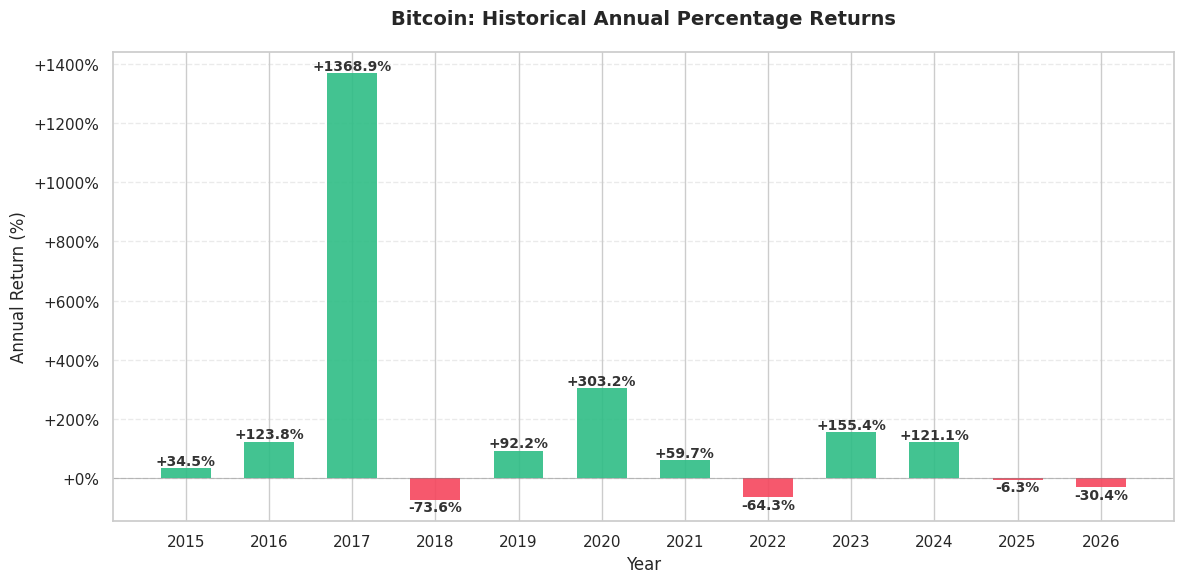

In [77]:
# Configure visual theme for the canvas grid
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

# Resample daily closing prices to get the final price of each calendar year
annual_closes = bitcoin['Close'].resample('YE').last()

# Calculate the year-over-year percentage returns
annual_returns = annual_closes.pct_change() * 100

# Drop the first year if it lacks a prior year baseline to compute a valid change
annual_returns = annual_returns.dropna()

# Extract the year digits to use as discrete string labels along the horizontal axis
years = annual_returns.index.year.astype(str)
values = annual_returns.values

# Assign a green color to positive returns and a red color to negative returns
bar_colors = ['#2ebd85' if val >= 0 else '#f6465d' for val in values]

# Render the bar chart using the mapped cyclical color array
bars = ax.bar(years, values, color=bar_colors, edgecolor='none', alpha=0.9, width=0.6)

# Overlay precise numeric data labels above or below each individual bar
for bar in bars:
    height = bar.get_height()
    label_pos = height + 25 if height >= 0 else height - 25
    ax.annotate(f'{height:+.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, label_pos),
                xytext=(0, 0),
                textcoords="offset points",
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='#333333')

# Configure title strings, axis boundaries, and format annotations
ax.set_title('Bitcoin: Historical Annual Percentage Returns', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Annual Return (%)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)

# Ensure a clear horizontal baseline exists at exactly 0%
ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

# Format the vertical axis markers to display distinct percentage signs
ax.yaxis.set_major_formatter('{x:+.0f}%')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

# Compress layout boundaries and commit the graphic directly to disk
plt.tight_layout()

##  Quarterly returns bar chart

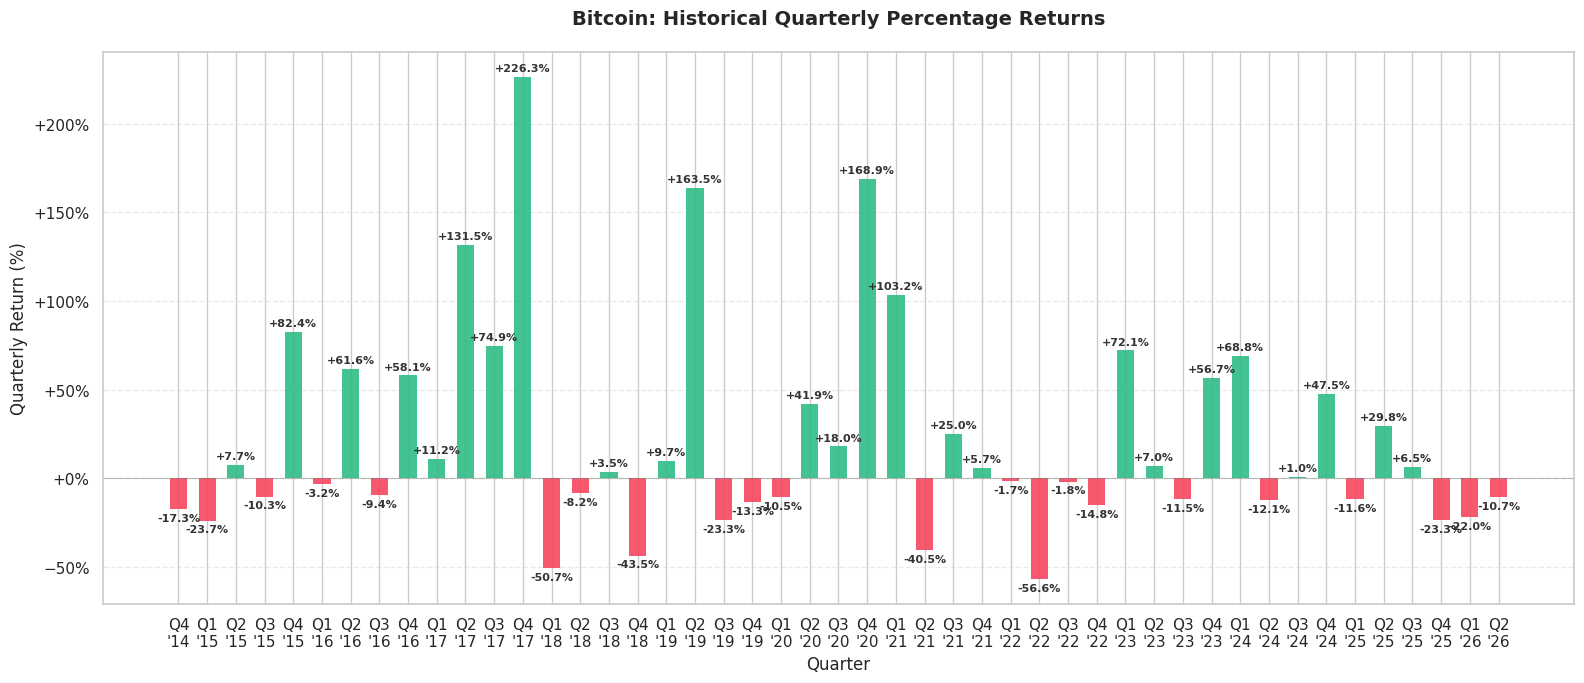

In [78]:
# Configure visual theme for the canvas grid
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(16, 7)) # Increased figure width for more bars

# Resample daily closing prices to get the final price of each calendar quarter
quarterly_closes = bitcoin['Close'].resample('QE').last()

# Calculate the quarter-over-quarter percentage returns
quarterly_returns = quarterly_closes.pct_change() * 100

# Drop the first quarter if it lacks a prior quarter baseline to compute a valid change
quarterly_returns = quarterly_returns.dropna()

# Extract the year and quarter digits to use as discrete string labels along the horizontal axis
# Format as 'QX\n'YY'
quarters = [f"Q{q.quarter}\n'{str(q.year)[-2:]}" for q in quarterly_returns.index.to_period('Q')]
values = quarterly_returns.values

# Assign a green color to positive returns and a red color to negative returns
bar_colors = ['#2ebd85' if val >= 0 else '#f6465d' for val in values]

# Render the bar chart using the mapped cyclical color array
bars = ax.bar(quarters, values, color=bar_colors, edgecolor='none', alpha=0.9, width=0.6)

# Overlay precise numeric data labels above or below each individual bar
for bar in bars:
    height = bar.get_height()
    # Adjust label position for better visibility, especially for smaller bars
    if height >= 0:
        label_pos = height + 5 # Small offset above the bar
    else:
        label_pos = height - 5 # Small offset below the bar
    ax.annotate(f'{height:+.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, label_pos),
                xytext=(0, 0),
                textcoords="offset points",
                ha='center', va='center', fontsize=8, fontweight='bold',
                color='#333333')

# Configure title strings, axis boundaries, and format annotations
ax.set_title('Bitcoin: Historical Quarterly Percentage Returns', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Quarterly Return (%)', fontsize=12)
ax.set_xlabel('Quarter', fontsize=12)

# Ensure a clear horizontal baseline exists at exactly 0%
ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

# Format the vertical axis markers to display distinct percentage signs
ax.yaxis.set_major_formatter('{x:+.0f}%')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

# Compress layout boundaries and commit the graphic directly to disk
plt.tight_layout()
plt.show()

##   Calendar heatmap — month × year grid of monthly returns

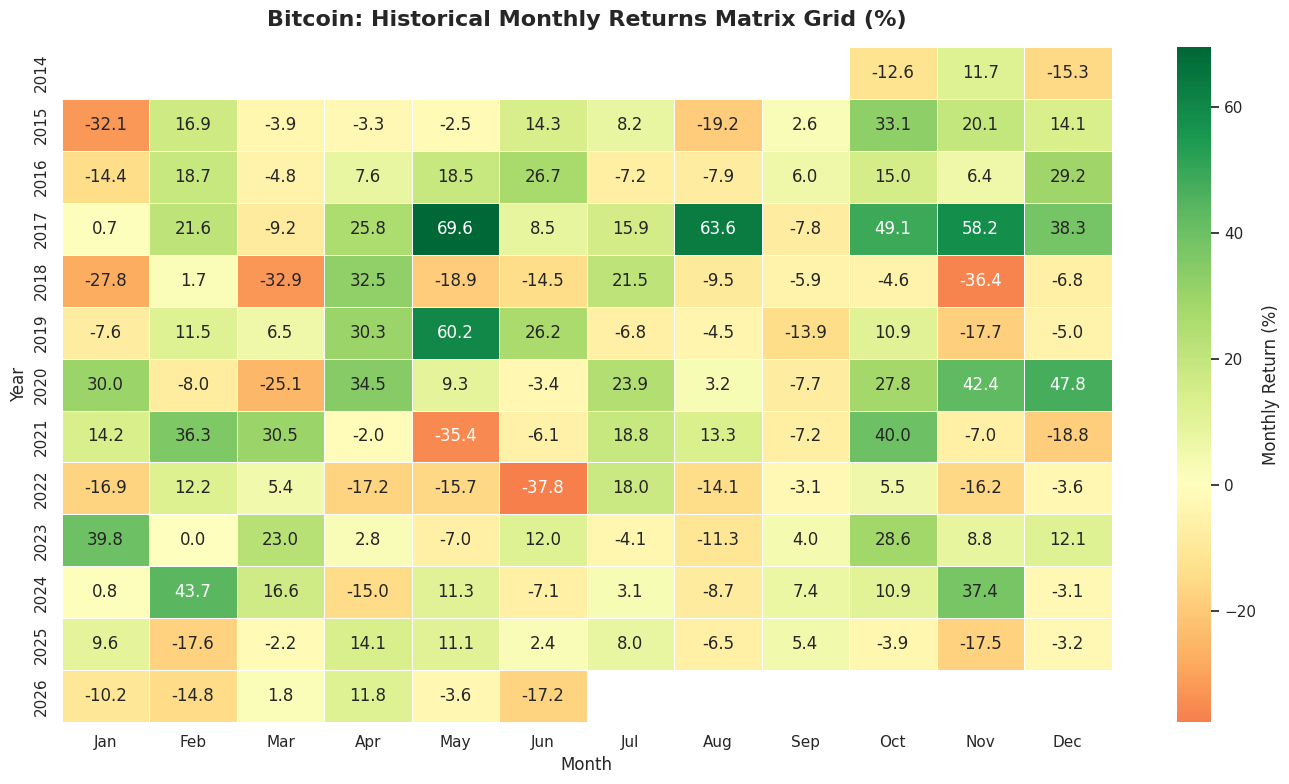

In [81]:
# Aggregate daily price data into monthly intervals using Month End (ME) resampling
monthly_closes = bitcoin["Close"].resample("ME").last()

# Calculate the sequential month-over-month percentage returns
monthly_returns = monthly_closes.pct_change() * 100

# Restructure the series into a DataFrame with distinct time-index features
monthly_df = monthly_returns.to_frame(name="Return")
monthly_df["Year"] = monthly_df.index.year
monthly_df["Month"] = monthly_df.index.month

# Pivot the rows and columns to structure the 2D matrix grid layout
seasonality_matrix = monthly_df.pivot(
    index="Year", columns="Month", values="Return"
)

# Replace the numerical column tags (1-12) with standard calendar month strings
month_names = [    "Jan",    "Feb",    "Mar",    "Apr",    "May",    "Jun",
               "Jul",    "Aug",    "Sep",    "Oct",    "Nov",    "Dec",]
seasonality_matrix.columns = month_names

# Render the Seasonal Calendar Heatmap
# Set a background without underlying grid lines
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(14, 8))

# Map the matrix using a diverging color space (Red = Losses, Green = Gains, Yellow = Neutral)
sns.heatmap(
    seasonality_matrix,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    cbar_kws={"label": "Monthly Return (%)"},
    linewidths=0.5,
    ax=ax,
)

# Configure the visual boundaries, headers, structural labels, and output formatting
ax.set_title(
    "Bitcoin: Historical Monthly Returns Matrix Grid (%)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Year", fontsize=12)

# Ensure the borders fit
plt.tight_layout()